(monotonic-ray)=

# 单调平滑插值

单调平滑插值，目的是：给定一组数据$(x,y)$，建立一个全局上函数单调的插值函数。因此它分为两步，一个步骤是平滑，一个步骤是插值。平滑使得数据单调，然后再使用保单调的插值函数进行插值。


## 单调插值
给定一组数据 $(x,y)$, `Gal3D` 应用了 [PCHIP 插值器](https://doi.org/10.1137/0905021) 的插值方法。该方法不仅能够提供高质量的插值结果，还能保持数据的单调性和局部形状特征。



假设给定数据点 $x_1<x_2< \cdots <x_n (n \geq 2)$, 以及对应的 $y_i = f(x_i), i=1,\dots,n$

需要确定插值函数的形式为：

$$
f_i(x) = a_i(x - x_i)^3 + b_i(x - x_i)^2 + c_i(x - x_i) + d_i
$$


其中，定义变量 $ \Delta x_i = x_{i+1} - x_i $ ; $ \Delta y_i = y_{i+1} - y_i $ ; 斜率则为 $ \Delta _i = \Delta y_i/\Delta x_i$

**确定每个节点处的导数**

对于端点 $x_1$ 和 $x_n$: 
如果只有两个节点$(n = 2)$, 直接设置导数为斜率： $ f_{1}^{'} = \Delta _1, f_{2}^{'} = \Delta _1 $ 

如果节点数 $n > 2$，使用 Fritsch-Butland 方法计算：

左侧端点的预期导数 为 $G_1 = [(2\Delta x_1 + \Delta x_2)\Delta _1 - \Delta x_1 \Delta _2]/(\Delta x_1 + \Delta x_2)$，实际为：

$$ f_{1}^{'} = 
\begin{cases}
0  &  G_1 \cdot \Delta_1 \leq 0, \\
3\Delta_1   &  \Delta_1 \cdot \Delta_2 < 0 \text{ and } |G_1| > 3|\Delta_1|, \\
G_1  & \text{otherwise.} \\
\end{cases} $$

右侧端点的预期导数为：$G_n = [(2\Delta x_{n-1} + \Delta x_{n-2})\Delta _{n-1} - \Delta x_{n-1} \Delta _{n-2}]/(\Delta x_{n-1} + \Delta x_{n-2})$，实际为：

$$ f_{n}^{'} = 
\begin{cases} 0  &  G_n \cdot \Delta_{n-1} \leq 0, \\
3\Delta_{n-1}   &  \Delta_{n-1} \cdot \Delta_{n-2} < 0 \text{ and } |G_n| > 3|\Delta_{n-1}|, \\ G_n  & \text{otherwise.}\\ \end{cases}$$

对于内部节点 $x_k$ 处的预期导数为：$G_k =\Delta_k \Delta_{k-1} \frac{W_1 + W_2}{W_1 \Delta_k+ W_2 \Delta_{k-1}}$，其中 $W_1 = 2\Delta x_k + \Delta x_{k-1}, \quad W_2 = \Delta x_k + 2\Delta x_{k-1}$，实际为：

$$f_{k}^{'} = \begin{cases} 0  & \Delta_{k} \cdot \Delta_{k-1} \leq 0, \\G_k  & \text{otherwise.}\\ \end{cases}$$


**计算插值函数的系数**

在得到 $f_{i}^{'}, f_{i+1}^{'}$ 后，插值函数的系数计算如下：
   - 常数项系数：

$$d_i = y_i$$

   - 一次项系数：

$$c_i = f_{i}^{'}$$

   - 二次项系数：

$$b_i = \frac{3\Delta_i - 2f_{i}^{'} - f_{i+1}^{'}}{\Delta x_i}$$

   - 三次项系数：

$$a_i = \frac{f_{i}^{'} + f_{i+1}^{'} - 2 \Delta_i}{\Delta x_i \Delta x_i}$$

## 单调平滑

对于沿单条射线采样得到的数据 $(x,y)$，其中 $x$ 单调递增，而 $y$ 由于噪声、离散采样或局部子结构可能出现局部回升，因此原始数据通常并不满足全局单调性。  
在 ``Gal3D`` 中，我们希望构造一个既尽量贴近原始数据、又在整体上保持单调的平滑函数，以便后续稳定地进行反函数求解，即从给定函数值反推出对应的半径。

设原始采样点为

$$
x_1 < x_2 < \cdots < x_n,\qquad y_i = y(x_i).
$$

下面以目标函数整体单调递减为例说明。若目标为单调递增，可等价地对序列反向后应用同样的步骤。

### 1. 构造单调上下包络

首先从原始数据中提取单调下包络与上包络的节点集合：

$$
\mathcal{L}=\{\,j \mid y_j=\min_{k\le j} y_k\,\},
\qquad
\mathcal{U}=\{\,j \mid y_j=\max_{k\ge j} y_k\,\}.
$$

其中：

- $\mathcal{L}$ 给出从内向外扫描时不断更新的累计最小值，因此对应单调下边界；
- $\mathcal{U}$ 给出从外向内扫描时不断更新的累计最大值，因此对应单调上边界。

利用这两组节点分别做 PCHIP 插值，可得到上下两条保单调的包络函数：

$$
y_{\rm lower}(x),\qquad y_{\rm upper}(x).
$$

PCHIP 的优点是既能保持单调性，也能尽量保留局部形状，并避免普通三次样条常见的过冲问题。

### 2. 以局部统计方式组合上下包络

若直接取

$$
\frac{y_{\rm upper}(x)+y_{\rm lower}(x)}{2},
$$

虽然也能得到一条位于包络之间的曲线，但它无法反映原始数据在各个局部区间内更偏向上包络还是下包络。  
因此 Gal3D 采用分段加权的方式来组合两条包络。

先取上下包络的共享节点作为区间边界，将整个定义域划分为若干区间 $I_m$。在每个区间内，记：$N_m$ 为该区间内原始采样点的总数，$N_{{\rm above},m}$ 为该区间内位于中线之上的采样点数，其中中线定义为

$$
y_{\rm mid}(x)=\frac{y_{\rm upper}(x)+y_{\rm lower}(x)}{2}.
$$

然后定义该区间的权重为

$$
w_m = \frac{1+N_{{\rm above},m}}{2+N_m}.
$$

于是该区间上的平滑函数写为

$$
\tilde y(x)
=
w_m\,y_{\rm upper}(x)
+
(1-w_m)\,y_{\rm lower}(x),
\qquad x\in I_m.
$$

由此：

- 因为 $0<w_m<1$，所以 $\tilde y(x)$ 始终位于上下包络之间；
- 因为 $y_{\rm lower}(x)$ 和 $y_{\rm upper}(x)$ 本身都单调递减，而 $w_m$ 在每个区间内为常数，所以 $\tilde y(x)$ 在每个区间内仍保持单调递减。

从直观上说，如果某个区间里的原始点更多地靠近上包络，则 $w_m$ 更大，平滑结果也更靠近上包络；反之则更靠近下包络。

### 3. 最终插值函数

得到分段定义的 $\tilde y(x)$ 后，再对其进行一次 PCHIP 插值，构造最终的平滑单调函数

$$
\hat y(x).
$$

这样得到的 $\hat y(x)$ 同时满足：

- 整体单调；
- 曲线连续且足够平滑；
- 在局部上仍保留原始数据的主要趋势；
- 可稳定构造反函数 $x(\hat y)$，用于根据目标密度反求对应半径。

下图展示了一个示例：黑色点为原始数据，绿色线为上下边界，红色线为目标单调平滑插值函数。

In [6]:
import numpy as np
data = np.load("../_static/data/monotonic_ray_xy.npz")
x = data["x"]
y = data["y"]

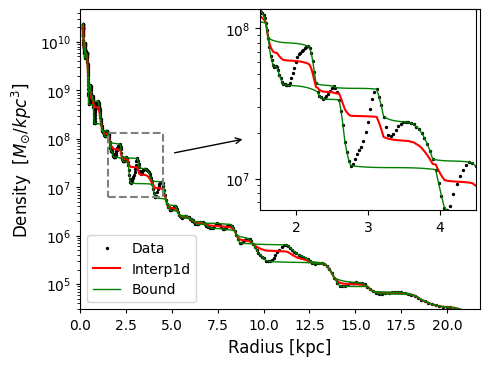

In [7]:
from gal3d.field.spherical_field import MonotonRay
import matplotlib.pyplot as plt

ray = MonotonRay(x,y,is_decreasing=True)



fig = plt.figure(dpi=100,figsize=(4,3))
ax1 = fig.add_axes((0,0,1,1))



ax1.scatter(x,y,s=2,c='k',label='Data')

ax1.plot(x,ray(x),color='r',label="Interp1d")
ax1.plot(x,ray.lower(x),color='g',linewidth = 1, label='Bound')
ax1.plot(x,ray.upper(x),color='g',linewidth = 1)

ax1.legend(loc='lower left')

ax1.set_yscale('log')
ax1.set_xlim(0,x[-1]+1)
ax1.set_ylim(3e4,)

ax2 = fig.add_axes((0.45, 0.33, 0.54, 0.67))

sel = (x>1.5)&(x<4.5)

ax2.scatter(x[sel],y[sel],s=2,c='k')
ax2.plot(x[sel],ray(x[sel]),color='r',label="Interp1d")
ax2.plot(x[sel],ray.lower(x[sel]),color='g',linewidth = 1, label='Bound')
ax2.plot(x[sel],ray.upper(x[sel]),color='g',linewidth = 1)

ax2.set_yscale('log')
ax2.set_xlim(1.5,4.5)
ax2.set_ylim(np.min(y[sel]),np.max(y[sel]))

y1,y2 = ax2.get_ybound()
x1,x2 = ax2.get_xbound()
ax1.plot([x1,x2,x2,x1,x1],[y1,y1,y2,y2,y1],c='grey',linestyle="--")

import matplotlib.patches as mpatches

arrow = mpatches.FancyArrowPatch((5, 5e7), (9, 1e8),
                                 mutation_scale=10,arrowstyle="->")
ax1.add_patch(arrow)

ax1.set_xlabel("Radius [kpc]",fontsize=12)
ax1.set_ylabel(r'Density $\ [M_{\odot}/kpc^3]$',fontsize=12)

ax1.xaxis.set_tick_params()

ax1.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True, labeltop=False,size=3,labelsize=10)
ax1.tick_params(axis='y', size=3,labelsize=10)
plt.show()